In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv

In [2]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    max_new_tokens=256,
    temperature=0.7
)

chat_model = ChatHuggingFace(llm=llm)

response = chat_model.invoke("Who are you?")
print(response.content)


I'm an artificial intelligence model known as a large language model (LLM). I'm a computer program designed to understand and generate human-like text. I can process and respond to a wide range of questions and topics, from simple to complex.

I'm often referred to as a "chatbot" or a "conversational AI." My primary function is to assist and provide information to users through text-based conversations. I can help with tasks such as answering questions, generating text, providing definitions, and even creating creative content like stories or dialogues.

I'm not a human, but I'm designed to be helpful and engaging. I can understand and respond to emotions, tone, and language in a way that simulates human-like conversation. However, I'm not perfect, and I may make mistakes or not understand certain nuances of language.

How can I assist you today?


In [3]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10 for the essay", ge=0, le=10)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.output_parsers import PydanticOutputParser

parser = PydanticOutputParser(pydantic_object=EvaluationSchema)

prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an expert essay evaluator.\n"
     "Return ONLY valid JSON that matches the given schema.\n"
     "Do not include explanations or extra text.\n"
     "{format_instructions}"
    ),
    ("human", "Evaluate the following essay:\n\n{essay}")
])

chain = prompt | chat_model | parser

In [5]:
class EssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [6]:
def evaluate_language(state: EssayState):
    prompt = ChatPromptTemplate.from_messages([
        ("system",
        "You are an expert essay evaluator.\n"
        "Return ONLY valid JSON that matches the given schema.\n"
        "Do not include explanations or extra text.\n"
        "Focus ONLY on language: grammar, vocabulary, sentence structure, and word choice.\n"
        "The JSON must have two keys: 'feedback' (string) and 'score' (number from 0 to 10).\n"
        "{format_instructions}"
        ),
        ("human",
        "Evaluate the language quality of the following essay. "
        "Provide feedback specifically about grammar, vocabulary, and sentence structure, "
        "and assign a score out of 10:\n\n{essay}"
        )
    ])
    chain = prompt | chat_model | parser
    result = chain.invoke({
        "essay": state["essay"],
        "format_instructions": parser.get_format_instructions(),
    })

    return {'language_feedback': result.feedback, 'individual_scores':[result.score]}

In [7]:
def evaluate_analysis(state: EssayState):
    prompt = ChatPromptTemplate.from_messages([
        ("system",
        "You are an expert essay evaluator.\n"
        "Return ONLY valid JSON that matches the given schema.\n"
        "Do not include explanations or extra text.\n"
        "Focus ONLY on language: grammar, vocabulary, sentence structure, and word choice.\n"
        "The JSON must have two keys: 'feedback' (string) and 'score' (number from 0 to 10).\n"
        "{format_instructions}"
        ),
        ("human",
        "Evaluate the depth of analysis of the following essay. "
        "Provide feedback specifically about logic, reasoning, use of evidence, and critical thinking, "
        "and assign a score out of 10:\n\n{essay}"
        )
    ])
    chain = prompt | chat_model | parser
    result = chain.invoke({
        "essay": state["essay"],
        "format_instructions": parser.get_format_instructions(),
    })

    return {'analysis_feedback': result.feedback, 'individual_scores':[result.score]}

In [8]:
def evaluate_thought(state: EssayState):
    prompt = ChatPromptTemplate.from_messages([
        ("system",
        "You are an expert essay evaluator.\n"
        "Return ONLY valid JSON that matches the given schema.\n"
        "Do not include explanations or extra text.\n"
        "Focus ONLY on language: grammar, vocabulary, sentence structure, and word choice.\n"
        "The JSON must have two keys: 'feedback' (string) and 'score' (number from 0 to 10).\n"
        "{format_instructions}"
        ),
        ("human",
        "Evaluate the clarity of thought of the following essay. "
        "Provide feedback specifically about coherence, logical flow, organization, and clarity of ideas, "
        "and assign a score out of 10:\n\n{essay}"
        )
    ])
    chain = prompt | chat_model | parser
    result = chain.invoke({
        "essay": state["essay"],
        "format_instructions": parser.get_format_instructions(),
    })

    return {'clarity_feedback': result.feedback, 'individual_scores':[result.score]}

In [9]:
def final_evaluation(state: EssayState):
    prompt = f"Based on following feedbacks create a summarized feedback \n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']} \n clarity of thought feedback {state['clarity_feedback']}"
    overall_feedback = chat_model.invoke(prompt)

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [10]:
graph = StateGraph(EssayState)
 
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('final_evaluation', final_evaluation)

In [11]:
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_thought')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('final_evaluation',END)

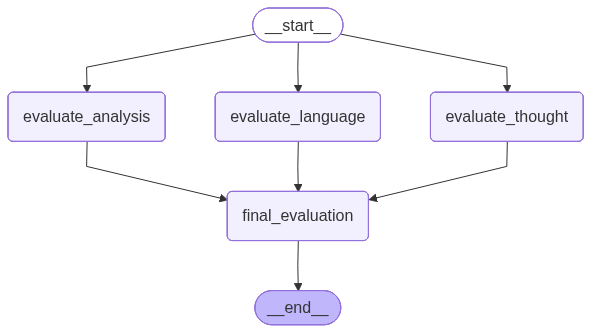

In [12]:
workflow = graph.compile()
workflow


In [13]:
out = chat_model.invoke("write an essay on topic AI in pakistan with bad language structure, very good clarity of thought but poor analysis")
essay = out.content

In [14]:
initial_state = {
    'essay': essay
}
workflow.invoke(initial_state)

OutputParserException: Failed to parse EvaluationSchema from completion {"feedback": "The essay demonstrates a clear thought process, but lacks in-depth analysis and supporting evidence. The organization is generally good, but the logical flow could be improved by providing more coherent transitions between ideas. The clarity of ideas is decent, but the use of colloquial language and simplistic explanations detract from the overall impact. To improve, the writer should focus on providing more nuanced arguments, supporting their claims with evidence, and refining their language to convey a more sophisticated tone.", "score": 7.5}. Got: 1 validation error for EvaluationSchema
score
  Input should be a valid integer, got a number with a fractional part [type=int_from_float, input_value=7.5, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/int_from_float
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/OUTPUT_PARSING